# Sprint 12 - Modelos No Supervisados (Sesiones)

En el presente caso de estudio daremos una primera aproximación a los modelos de aprendizaje **no supervisado**. A diferencia de los modelos supervisados, donde el objetivo consiste en aprender una relación entre atributos y una variable objetivo conocida, los modelos no supervisados trabajan únicamente con las variables descriptivas disponibles en los datos. Su propósito por tanto es identificar estructuras, agrupamientos, relaciones o comportamientos que existen de manera natural dentro de la información, sin que exista una respuesta correcta previamente definida.

Este enfoque resulta especialmente valioso en situaciones donde no se dispone de etiquetas o clasificaciones previas sobre las observaciones analizadas. En muchos contextos empresariales y científicos, las organizaciones cuentan con grandes volúmenes de información pero desconocen qué patrones relevantes podrían encontrarse en ellos. Los algoritmos no supervisados permiten precisamente explorar estos conjuntos de datos para descubrir conocimientos latentes, identificar segmentos homogéneos, detectar comportamientos inusuales o simplificar la representación de información compleja.

Debido a estas características, el aprendizaje no supervisado posee una amplia variedad de aplicaciones, Entre las que se encuentran:

* Transformación de variables: permite reducir, resumir o reorganizar la información contenida en múltiples atributos para facilitar su análisis y utilización posterior. Estas técnicas resultan especialmente útiles por ejemplo cuando se trabaja con conjuntos de datos de alta dimensionalidad. Es importante destacar que ya hemos utilizado uno de estos métodos en el proyecto anterior a fin de poder visualizar datos multidimensionales: El *Análisis de Componentes Principales (PCA)*.
* Sistemas de recomendación: utilizan patrones de comportamiento, preferencias o hábitos de consumo para identificar similitudes entre usuarios y productos, permitiendo generar sugerencias personalizadas que incrementan la experiencia del cliente y las oportunidades de negocio. Estos sistemas se constituyen en una de las aplicaciones más conocidas, pues compañías como Amazon o Netflix los vienen usando desde hace bastante tiempo para sugerir productos y contenidos que probablemente resulten atractivos para cada usuario, mejorando además la experiencia de uso en sus plataformas.
* Perfilamiento o segmentación: buscan agrupar observaciones con características similares para identificar perfiles diferenciados de clientes, usuarios, productos o cualquier otra entidad de interés.
* Detección de anomalías: permiten identificar registros cuyo comportamiento difiere significativamente del observado en la mayoría de las observaciones, lo que puede resultar útil para detectar fraudes, errores, eventos excepcionales o situaciones de riesgo.

Volviendo a nuestro caso de estudio, nos concentraremos particularmente en las dos últimas aplicaciones mencionadas del aprendizaje no supervisado: el perfilamiento y la detección de anomalías. Para abordar estos problemas utilizaremos uno de los algoritmos más conocidos dentro del análisis de agrupamientos basado en densidad: **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**. A diferencia de otros métodos de segmentación, **DBSCAN** no requiere especificar previamente un número de grupos que se desea encontrar y posee la capacidad de identificar observaciones aisladas o anómalas de forma natural. Su funcionamiento se basa en la idea de que los grupos están formados por regiones de alta densidad de observaciones separadas por zonas de baja densidad.

Gracias a estas características, **DBSCAN** se ha convertido en una herramienta ampliamente utilizada para segmentación de clientes, análisis geoespacial, detección de fraudes, monitoreo de sistemas, análisis de comportamiento y muchas otras aplicaciones donde resulta importante descubrir estructuras ocultas dentro de los datos. A lo largo de este caso práctico aprenderemos entonces cómo funciona este algoritmo, cuáles son sus principales parámetros y cómo interpretar los resultados obtenidos para generar conocimiento útil a partir de la información disponible.

## Entendimiento del contexto

Una tienda minorista especializada en la venta de artículos de vestimenta, ubicada en un importante centro comercial, ha experimentado un crecimiento sostenido en su base de clientes durante los últimos años. Como resultado, la empresa ha acumulado una cantidad significativa de información relacionada con las características demográficas, hábitos de compra y comportamiento de sus consumidores. Sin embargo, la dirección considera que aún no está aprovechando plenamente el potencial de estos datos para comprender mejor a sus clientes y desarrollar estrategias comerciales más efectivas.

Uno de los principales objetivos de la organización es identificar y caracterizar los diferentes perfiles de clientes que conforman su mercado. En marketing, estos perfiles suelen denominarse *buyer personas* y representan grupos de consumidores con características, necesidades y comportamientos similares. Comprender adecuadamente estos segmentos permite diseñar campañas publicitarias más relevantes, personalizar promociones, optimizar la oferta de productos y mejorar la experiencia general de compra. En un entorno altamente competitivo, conocer a los clientes se ha convertido en una ventaja estratégica fundamental para aumentar la efectividad de las acciones comerciales.

Para lograr este objetivo, la empresa busca ir más allá de una simple descripción demográfica de sus consumidores. Aunque variables como edad, género o nivel de ingresos pueden aportar información útil, la experiencia demuestra que las preferencias, hábitos y comportamientos de compra suelen ser mucho más representativos al momento de comprender a una persona. Por ejemplo, dos clientes de edades similares pueden presentar patrones de consumo completamente distintos, mientras que personas de generaciones diferentes pueden compartir gustos y comportamientos muy parecidos. Por esta razón, el análisis se debe enfocarse especialmente en variables que reflejen acciones, preferencias y decisiones de compra, ya que estas permiten construir perfiles más precisos y útiles para la toma de decisiones.

Adicionalmente, la empresa desea identificar posibles clientes atípicos dentro de la información recopilada durante el último año. Estos casos pueden corresponder a consumidores con patrones de compra significativamente diferentes al resto. Detectar este tipo de observaciones resulta especialmente valioso, ya que algunos de estos clientes pueden representar oportunidades estratégicas para el negocio, como compradores de alto valor, mientras que otros podrían requerir un análisis más detallado para comprender las razones detrás de su comportamiento.

Con el propósito de alcanzar ambos objetivos, la empresa ha decidido apoyarse en técnicas de análisis y ciencia de datos que permitan descubrir patrones presentes en la información de sus clientes. Como especialista en esta área, tu tarea consistirá en desarrollar un proceso de perfilamiento que identifique segmentos homogéneos de consumidores y, al mismo tiempo, detectar posibles anomalías o comportamientos atípicos dentro de los datos. Los resultados obtenidos permitirán a la organización diseñar estrategias de marketing más personalizadas, mejorar la relación con sus clientes y orientar de manera más eficiente sus esfuerzos comerciales hacia aquellos segmentos que generan mayor valor para el negocio.

## Entendimiento de los datos

Importa las librerías con las que trabajarás. Además de las que usualmente utilizas, carga lo siguiente:

* **Seaborn** que es una librería gráfica complementaria a **matplotlib** y aprovecharemos este proyecto para aprender un poco sobre ella.
* La función **MinMaxScaler** y el módulo **metrics** de **Skikit-Learn**.
* La función **DBSCAN** del módulo **cluster** de **Scikit-Learn**. 

In [1]:
#Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.cluster import DBSCAN

import warnings
warnings.filterwarnings("ignore")

La empresa te ha compartido la información contenida en el archivo [**mall_customers.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/mall_customers.csv) el cual cuenta con información de 200 clientes en el último año.

In [2]:
# Cargar datos
df_clientes = pd.read_csv("https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/mall_customers.csv")

# Mostrar estructura de los datos
df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Genre                   200 non-null    str  
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


Esta tabla consta de las siguientes columnas:

* Genre: El genero del cliente (Male, Female).
* Age: La edad del cliente.
* Annual Income (k$): El ingreso monetario reportado por cada cliente en una encuesta que realizó el local previamente.
* Spending Score (1-100): Una calificación propia del local que califica entre 1 y 100 a cada cliente de acuerdo a su nivel de consumo de sus productos.

Explora su contenido para generar a partir de allí un objetivo técnico, un detalle de los algoritmos y métricas a utilizar, y un plan de acción para preparación e ingeniería de datos.

In [3]:
# Generar muestra de los datos
df_clientes.sample(10)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
80,Male,57,54,51
87,Female,22,57,55
140,Female,57,75,5
182,Male,46,98,15
136,Female,44,73,7
183,Female,29,98,88
49,Female,31,40,42
74,Male,59,54,47
125,Female,31,70,77
155,Female,27,78,89


In [4]:
# Mostrar un conteo de casos por genero
df_clientes["Genre"].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [5]:
# Generar resumen estadístico de las variables numericas
df_clientes.describe(include = int).round(2)

,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


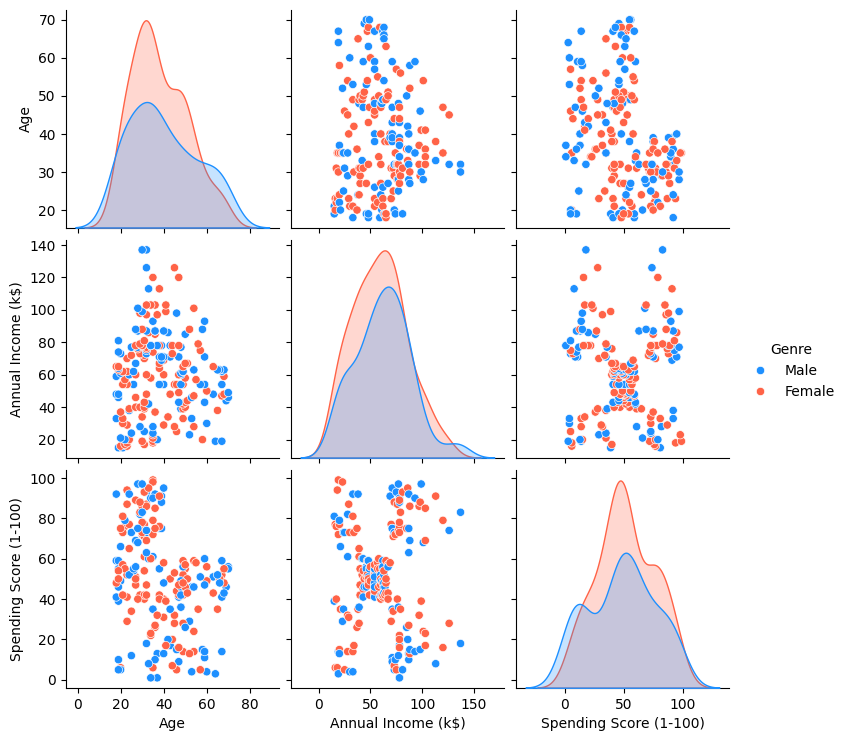

In [6]:
# Visualizar distribución y correlación de las variables
sns.pairplot(
    data = df_clientes,
    hue = "Genre",
    palette = {"Male":"dodgerblue", "Female":"tomato"}
)
plt.show()

**OBJETIVO TÉCNICO**

* Identificar de manera asertiva grupos de clientes a partir de atributos asociados a sus características y comportamientos de consumo, en concreto su ingreso anual y la calificación de gasto. Para esto se implementará un modelo no supervisado para segmentación.
* Extraer casos atípicos de clientes cuyos atributos sean significativamente distintos a otros casos. El algoritmo del modelo implementado en el objetivo anterior igualmente puede ser de utilidad para este propósito siempre que el mismo sea capaz de detectar anomalías. 

**MÉTODO Y MÉTRICAS DE RENDIMIENTO**

* Algoritmo: **DBSCAN**.
* Métricas de rendimiento: **Silueta**, **Índice Calinsky-Harabasz (CHI)**, **Índice Davies-Bouldin (DBI)**.

**PLAN DE ACCIÓN PARA PREPARACIÓN E INGENIERÍA DE DATOS**

| # | Acción de preparación |
| ---- | ---- |
| 1 | Se deben ajustar los nombres de las columnas para que cumplan con los criterios *snake_case*. |
| 2 | Se tienen que separar los atributos en aquellos que muestran características demográficas (género y edad) y los que especifican comportamientos (ingresos y score de consumo). Estos últimos son aquellos que servirán como atributos para el modelo a desarrollar. |

<br />

| # | Acción de ingeniería |
| ---- | ---- |
| 1 | Hay que escalar los atributos a fin que los mismos se encuentren en ordenes de magnitud similares. Esto es relevante considerando que los algoritmos para modelos no supervisados suelen basarse en conceptos de distancias, mismas que son sensibles a las escalas de los atributos. |

## Preparación de datos

Ejecuta tu plan de acción en lo referente a la preparación de los datos.

In [7]:
# Ajustar nombres de columnas a formato snake_case
df_clientes.columns = ["genre","age","income","spending"]
df_clientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   genre     200 non-null    str  
 1   age       200 non-null    int64
 2   income    200 non-null    int64
 3   spending  200 non-null    int64
dtypes: int64(3), str(1)
memory usage: 7.4 KB


In [8]:
# Separar el dataset entre variables demográficas y "conductuales"
df_demo = df_clientes[["genre","age"]]
X = df_clientes[["income","spending"]]
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   income    200 non-null    int64
 1   spending  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


## Ingeniería de atributos

Lleva a cabo tu plan de acción en los refernte a ingeniería de datos y culmina con una gráfica de dispersión entre los atributos utilizados.

In [9]:
# Escalar los atributos mediante normalizacion
variables = ["income","spending"]
normalizador = MinMaxScaler()
X[variables] = normalizador.fit_transform(X)
X.describe().round(2)

,income,spending
count,200.00,200.00
mean,0.37,0.50
std,0.22,0.26
min,0.00,0.00
25%,0.22,0.34
50%,0.38,0.50
75%,0.52,0.73
max,1.00,1.00


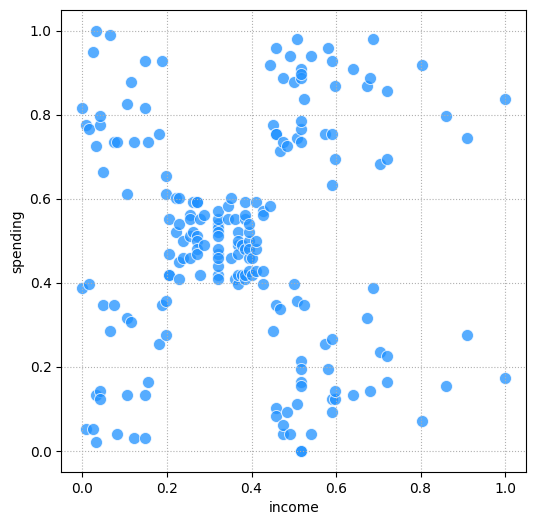

In [10]:
# Visualizar una dispersión de los datos escalados
plt.figure(figsize = [6,6])
sns.scatterplot(
    data = X,
    x = "income", 
    y = "spending",
    s = 75,
    alpha = 0.75,
    c = "dodgerblue"
)
plt.grid(linestyle = ":")
plt.show()

## Creación de modelo base

A diferencia de otros algoritmos para modelos de aprendizaje no supervisado, el **DBSCAN** permite la ejecución de dos tareas simultáneas: por una parte, agrupar los datos en grupos o segmentos; y además detectar valores atípicos o anómalos en la información.

En cuanto a estas tareas, el **DBSCAN** realiza el agrupamiento basándose en la distribución original de los datos y aplicando los siguientes criterios:

* Todos los datos que cuenten con un número "suficiente" de vecinos cercanos se denominan **puntos nucleares** y son candidatos a ser el centro de un grupo o *cluster*.
* Si dos o más **puntos nucleares** comparten una misma vecindad, se dice que están **denso - conectados**, y pueden unirse junto con todos sus vecinos para conformar un mismo cluster.
* Si un punto no pertenece a ninguna vecindad, se lo denomina un **punto aislado** y puede considerarse una anomalía.

![](https://github.com/jsaraujo5081/material_curso_data_science/blob/main/complementary_files/dbscan.PNG?raw=true)

En la gráfica anterior, nótese que los datos $n_i$ corresponden a puntos nucleares, y que de ellos $n_1$ no se encuentra denso - conectado a los demás, mientras que $n_2, n_3, n_4$ sí lo están entre ellos. Por tanto, se crean dos clusters distintos: el primero comprendido por $n_1$ y sus vecinos, y un segundo comprendido por los demás punto nucleares y sus vecinos. Adicionalmente, nótese que existen dos datos ($r_1$ y $r_2$) que no pertenecen a ninguna vecindad, éstos por tanto se consideran anomalías.

De lo anterior, se desprende que este algoritmo requiere de dos hiperparámetros:

* **epsilon** que corresponde al umbral de distancia de cada punto de datos para considerar a otras observaciones como sus vecinos. 
* **k** que corresponde al número mínimo de vecinos de cada punto para considerarlo como nuclear.

Utiliza la función **DBSCAN** para definir y entrenar un modelo basado en este algoritmo, incorporando además los argumentos `eps = 0.1` y `min_samples = 5` (estos son los hiperparámetros antes mencionados). 

In [11]:
# Crear modelo 
mod_DBSCAN = DBSCAN(
    eps = 0.1, 
    min_samples = 5
)

# Entrenar modelo
mod_DBSCAN.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.1
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Extrae los clusters identificados por el modelo para los datos con los que entrenó mediante el atributo `labels_`.

In [12]:
clusters = mod_DBSCAN.labels_
clusters

array([ 0,  0,  1,  0,  0,  0,  1, -1,  1,  0,  1, -1,  1,  0,  1,  0,  0,
        0,  0, -1,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  1,  0,  1,  0,
        1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,
        0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,
        2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,
        0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2,  0,  2, -1,  2,  0,
       -1,  0,  2,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1])

Incorpora estos resultados en el dataset original que contiene toda la información de clientes y guarda esto en un nuevo dataframe.

In [13]:
df_c = df_clientes.copy()
df_c["cluster"] = clusters
df_c.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   genre     200 non-null    str  
 1   age       200 non-null    int64
 2   income    200 non-null    int64
 3   spending  200 non-null    int64
 4   cluster   200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


Comprendamos los resultados alcanzados. El valor de **-1** en algunos registros evidencia que de acuerdo a este modelo estos son atípicos. Por su parte, el resto de clusters se representan por números mayores o iguales a 0, por lo que bajo este modelo base, existen 3 grupos de clientes.

Visualiza estos resultados mediante un gráfico de dispersión en el que los colores de los puntos den cuenta del cluster al que pertenece cada dato.

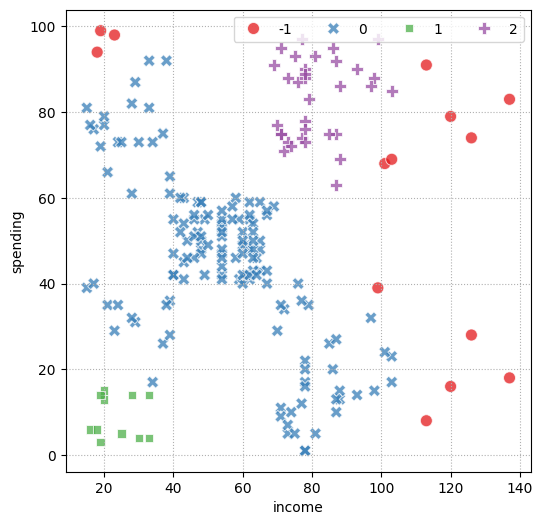

In [14]:
plt.figure(figsize = [6,6])
sns.scatterplot(
    data = df_c.sort_values(by = "cluster", ascending = False),
    x = "income",
    y = "spending",
    hue = "cluster",
    style = "cluster",
    palette = sns.color_palette("Set1", len(np.unique(clusters))),
    s = 75,
    alpha = 0.75
)
plt.legend(
    title = "", 
    ncols = len(np.unique(clusters))
)
plt.grid(linestyle = ":")
plt.show()

El modelo no parece estar agrupando de manera tan adecuada, aunque es capaz de identificar algunas anomalías que sí lo parecen al menos de forma visual. 

Confirma esta afirmación mediante el cálculo de las métricas de rendimiento **Silueta**, **DBI** y **CHI**, con las funciones `silhouette_score`, `calinski_harabasz_score`, `davies_bouldin_score`. Todas estas métricas requieren de dos argumentos: los atributos utilizados, y los clusters generados como resultado del entrenamiento.

In [15]:
silueta = metrics.silhouette_score(X, clusters)
chi = metrics.calinski_harabasz_score(X, clusters)
dbi = metrics.davies_bouldin_score(X, clusters)
print(f"Silueta: {silueta:.1%}")
print(f"Indice Calinsky-Harabasz: {chi:.1f}")
print(f"Indice Davies-Bouldin: {dbi:.1f}")

Silueta: 30.9%
Indice Calinsky-Harabasz: 48.0
Indice Davies-Bouldin: 1.6


En cuanto a estos indicadores debes saber lo siguiente:

* **Silueta**: Esta métrica es una medida de can similar es en promedio cada punto con su cluster asignado. Puede tomar valores entre -1 y 1, donde -1 especifica un agrupamiento de mala calidad, y 1 a aquel de buena calidad.
* **Índice Calinsky-Harabasz (CHI)**: Esta métrica mide la relación entre la variabilidad media entre-clusters y la variabilidad media intra-clusters. En este sentido, mientras mayor sea su valor se implica que los agrupamientos generados son densos y debidamente separados.
* **Índice Davies-Bouldin (DBI)**: Esta métrica mide el grado de similitud medio de cada cluster con su grupo más cercano. Por tanto, mientras más bajo sea su valor se implica que los agrupamientos más densos y debidamente separados.  

Visto esto, dada una siliueta de cerca de 31% podems afirmar que los resultados son parcialmente positivos aunque mejorables. 

## Optimización de modelo

Como vimos, el algoritmo **DBSCAN** cuenta con dos hiperparámetros que pueden modificarse para mejorar el rendimiento del modelo. Por tanto, encuentra los valores de *épsilon* y *k* que maximizan la métrica de Silueta. 

In [16]:
# Establecer posibles valores de hiperparámetros a probar
e_lista = np.array(range(1,40))/200
v_lista = np.array(range(2,21))

# Calcular silueta para distintas combinaciones de hiperparametros
sil_res = []
e_res = []
v_res = []

for e in e_lista:
    for v in v_lista:

        e_res.append(e)
        v_res.append(v)

        modelo = DBSCAN(eps = e, min_samples = v).fit(X)
        clusters = modelo.labels_

        if len(np.unique(clusters)) == 1:
            silueta = -1
        else:
            silueta = metrics.silhouette_score(X, clusters)
        
        sil_res.append(silueta)

df_opt = pd.DataFrame(dict(
    epsilon = e_res,
    vecinos = v_res,
    silueta = sil_res
))

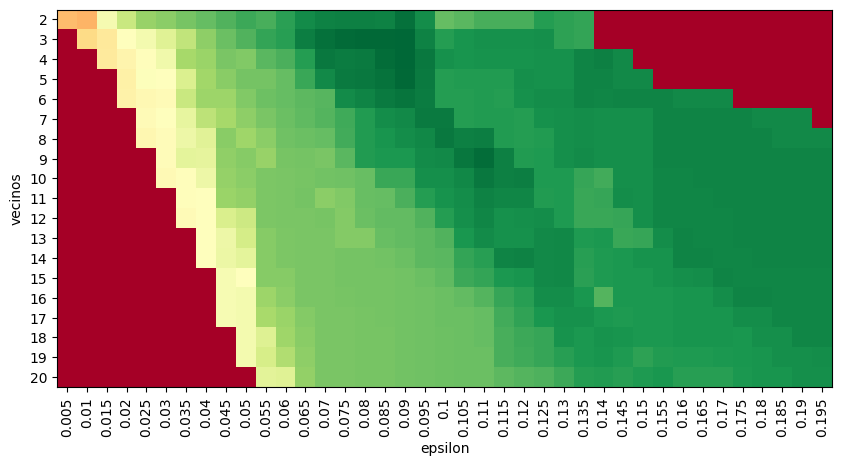

In [17]:
# Visualizar optimización con mapa de calor
df_heatmap = df_opt.pivot_table(
    index = "vecinos",
    columns = "epsilon",
    values = "silueta",
    aggfunc = "sum"
)

plt.subplots(figsize = [10,10])
plt.imshow(df_heatmap, cmap='RdYlGn')
plt.ylabel("vecinos")
plt.yticks(ticks = range(len(df_heatmap.index)), labels = df_heatmap.index)
plt.xlabel("epsilon")
plt.xticks(ticks = range(len(df_heatmap.columns)), labels = df_heatmap.columns, rotation = 90)
plt.show()

In [18]:
# Extraer valores óptimos
optimos = df_opt.sort_values(by = "silueta", ascending = False).iloc[0]
print(optimos)

epsilon    0.090000
vecinos    3.000000
silueta    0.481369
Name: 324, dtype: float64


Implementa estos valores para crear un modelo de agrupamiento y detección de anomalías óptimo.

In [19]:
# Crear y entrenar modelo optimizado
mod_DBSCAN_f = DBSCAN(
    eps = optimos["epsilon"], 
    min_samples = int(optimos["vecinos"])
)
mod_DBSCAN_f.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",np.float64(0.09)
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",3
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Incorpora los nuevos clusters en la tabla original y guarda el resultado en un nuevo dataset.

In [20]:
# Extraer los clusters
clusters = mod_DBSCAN_f.labels_
clusters

array([ 0,  1,  2,  1,  0,  1,  2,  3,  2,  1,  2,  3,  2,  1,  2,  1,  0,
        1,  0,  3,  0,  1,  2,  1,  2,  1,  0,  1,  0,  1,  2,  1,  2,  1,
        2,  1,  2,  1,  0,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  4,  0,  4,  0,  4,  5,  4,  5,  4,  0,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  0,  4,  5,  4,  0,  4,  5,  4,  5,  4,  5,
        4,  5,  4,  5,  4,  5,  4,  0,  4,  5,  4,  5,  4,  5,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  5,  4,  5,  4,  5,  4,  5,  4,  5,  4,  5,
       -1,  5,  4,  5, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [21]:
# Incorporar los clusters al dataset
df_c = df_clientes.copy()
df_c["cluster"] = clusters
df_c.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   genre     200 non-null    str  
 1   age       200 non-null    int64
 2   income    200 non-null    int64
 3   spending  200 non-null    int64
 4   cluster   200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


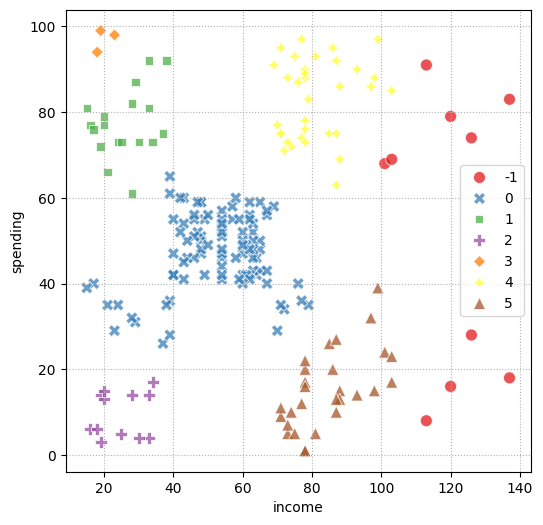

In [22]:
# Visualizar datos agrupados
plt.figure(figsize = [6,6])
sns.scatterplot(
    data = df_c.sort_values(by = "cluster", ascending = False),
    x = "income",
    y = "spending",
    hue = "cluster",
    style = "cluster",
    palette = sns.color_palette("Set1",len(np.unique(clusters))),
    s = 75,
    alpha = 0.75
)
plt.legend(title = "")
plt.grid(linestyle = ":")
plt.show()

Vuelve a evaluar el rendimiento de este modelo con las métricas establecidas.

In [23]:
silueta = metrics.silhouette_score(X, clusters)
chi = metrics.calinski_harabasz_score(X, clusters)
dbi = metrics.davies_bouldin_score(X, clusters)
print(f"Silueta: {silueta:.1%}")
print(f"Indice Calinsky-Harabasz: {chi:.1f}")
print(f"Indice Davies-Bouldin: {dbi:.1f}")

Silueta: 48.1%
Indice Calinsky-Harabasz: 152.5
Indice Davies-Bouldin: 0.7


El resultado alcanzado es bastante mejor en términos de asertividad generándose 6 tipologías de clientes distintas y un 5% de registros anómalos.

## Implementación de modelo en el negocio

Para concluir traduce estos resultados para responder a la problemática de negocios planteada. En primer lugar genera una descripción de las características demográficas (género y edad) y el comportamiento distintivo de los grupos de clientes encontrados.

In [24]:
perfiles = (
    df_c
    .query("cluster >= 0")
    .groupby("cluster")
    .agg(
        casos = ("cluster","count"),
        edad_med = ("age","median"),
        genero_moda = ("genre",lambda x: x.mode()[0]),
        income_med = ("income","median"),
        spending_med = ("spending","median")
    )
)
perfiles

,casos,edad_med,genero_moda,income_med,spending_med
cluster,,,,,
0,96,45.0,Female,54.0,48.0
1,18,23.0,Female,26.5,76.5
2,12,51.0,Female,22.5,9.5
3,3,35.0,Female,19.0,98.0
4,33,32.0,Female,78.0,86.0
5,28,41.5,Male,83.0,14.5


Finalmente, detalla aquellos casos que son anómalos para que la empresa los considere uno a uno.

In [25]:
clientes_anomalos = df_c.query("cluster == -1").drop(columns = "cluster")
clientes_anomalos

,genre,age,income,spending
187,Male,28,101,68
191,Female,32,103,69
192,Male,33,113,8
193,Female,38,113,91
194,Female,47,120,16
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18
199,Male,30,137,83
